In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon
from pandas.plotting import scatter_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV, KFold, GroupKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from torch.utils.data import TensorDataset, DataLoader

In [2]:
df = pd.read_table('HR_data.csv', sep=',', engine='python')
df

,Unnamed: 0,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Round,Phase,Individual,Puzzler,Frustrated,Cohort
0,0,77.965186,78.000,3.345290,73.23,83.37,22924.945,round_3,phase3,1,1,1,D1_1
1,1,70.981097,70.570,2.517879,67.12,78.22,21930.400,round_3,phase2,1,1,5,D1_1
2,2,73.371959,73.360,3.259569,67.88,80.22,21647.085,round_3,phase1,1,1,0,D1_1
3,3,78.916822,77.880,4.054595,72.32,84.92,25258.905,round_2,phase3,1,1,1,D1_1
4,4,77.322226,74.550,6.047603,70.52,90.15,23890.565,round_2,phase2,1,1,5,D1_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,163,73.594539,72.380,9.474556,57.43,93.53,21482.985,round_4,phase2,14,0,8,D1_2
164,164,57.839897,54.130,6.796647,52.97,74.14,16825.740,round_4,phase1,14,0,0,D1_2
165,165,64.237295,65.195,3.589241,58.97,72.63,18691.065,round_1,phase3,14,0,1,D1_2
166,166,70.834320,70.440,2.391160,66.65,76.07,20753.005,round_1,phase2,14,0,4,D1_2


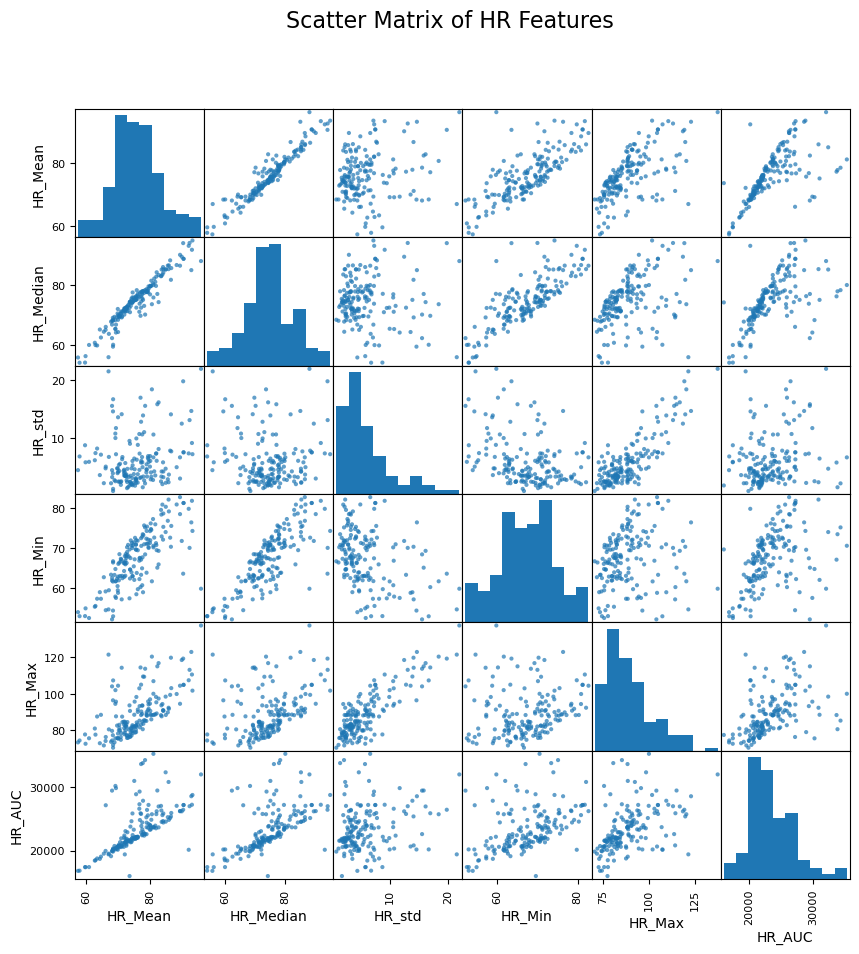

In [3]:
hr_cols = ['HR_Mean', 'HR_Median', 'HR_std', 'HR_Min', 'HR_Max', 'HR_AUC']
df_hr = df[hr_cols]

# Create scatter matrix
scatter_matrix(df_hr, alpha=0.7, figsize=(10, 10), diagonal='hist')
plt.suptitle("Scatter Matrix of HR Features", fontsize=16)
plt.show()

In [4]:
#df['HR_std_log'] = np.log(df['HR_std'])
#df['HR_max_log'] = np.log(df['HR_Max'])

In [5]:
#hr_cols = ['HR_Mean', 'HR_Median', 'HR_std_log', 'HR_Min', 'HR_max_log', 'HR_AUC']
#df_hr = df[hr_cols]

# Create scatter matrix
#scatter_matrix(df_hr, alpha=0.7, figsize=(10, 10), diagonal='hist')
#plt.suptitle("Scatter Matrix of HR Features", fontsize=16)
#plt.show()

In [15]:
# --- Set seeds for reproducibility ---
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# Load and preprocess data
df = pd.read_csv('HR_data.csv').drop(columns=['Unnamed: 0'])
df['Target'] = df['Frustrated']
df['TimeOrder'] = df['Round'] * 3 + df['Phase']
df.sort_values(by=['Individual', 'TimeOrder'], inplace=True)

# One-hot encode categorical features
categorical_features = ['Round', 'Phase', 'Cohort']
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe.fit(df[categorical_features])
groups = df['Individual']
y = df['Target']

outer_cv = GroupKFold(n_splits=5)
outer_results = {'Baseline': [], 'DecisionTree': [], 'NeuralNet': []}

for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(df, y, groups=groups)):
    print(f"\n=== Outer Fold {outer_fold + 1} ===")
    
    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()
    
    # Log-transform inside each fold
    train_df['HR_std_log'] = np.log(train_df['HR_std'] + 1e-6)
    test_df['HR_std_log'] = np.log(test_df['HR_std'] + 1e-6)
    train_df['HR_Max_log'] = np.log(train_df['HR_Max'] + 1e-6)
    test_df['HR_Max_log'] = np.log(test_df['HR_Max'] + 1e-6)
    train_df.drop(columns=['HR_std', 'HR_Max'], inplace=True)
    test_df.drop(columns=['HR_std', 'HR_Max'], inplace=True)

    # One-hot encode categorical features
    train_cats = ohe.transform(train_df[categorical_features])
    test_cats = ohe.transform(test_df[categorical_features])

    train_features = pd.concat([
        train_df.drop(columns=categorical_features + ['Frustrated', 'Target', 'TimeOrder']),
        pd.DataFrame(train_cats, columns=ohe.get_feature_names_out(categorical_features), index=train_df.index)
    ], axis=1)
    
    test_features = pd.concat([
        test_df.drop(columns=categorical_features + ['Frustrated', 'Target', 'TimeOrder']),
        pd.DataFrame(test_cats, columns=ohe.get_feature_names_out(categorical_features), index=test_df.index)
    ], axis=1)

    y_train_outer = train_df['Target']
    y_test_outer = test_df['Target']

    # Baseline model
    mean_baseline = np.mean(y_train_outer)
    baseline_preds = np.full_like(y_test_outer, mean_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test_outer, baseline_preds))
    outer_results['Baseline'].append(baseline_rmse)
    print(f"Baseline RMSE: {baseline_rmse:.4f}")

    # Decision Tree
    inner_cv = GroupKFold(n_splits=3)
    dt_param_grid = {'max_depth': [3, 5, 7], 'min_samples_split': [2, 5, 10]}
    dt = DecisionTreeRegressor(random_state=42)
    dt_grid = GridSearchCV(dt, dt_param_grid, 
                           cv=inner_cv.split(train_features, y_train_outer, groups=groups.iloc[train_idx]),
                           scoring='neg_mean_squared_error')
    dt_grid.fit(train_features, y_train_outer)
    dt_pred = dt_grid.best_estimator_.predict(test_features)
    dt_rmse = np.sqrt(mean_squared_error(y_test_outer, dt_pred))
    outer_results['DecisionTree'].append(dt_rmse)
    print(f"DT RMSE: {dt_rmse:.4f}")
    print(f"Selected Decision Tree Params: {dt_grid.best_params_}")

    # Neural Network
    scaler = StandardScaler().fit(train_features)
    X_train_scaled = scaler.transform(train_features)
    X_test_scaled = scaler.transform(test_features)

    class SimpleNN(nn.Module):
        def __init__(self, input_dim):
            super(SimpleNN, self).__init__()
            self.fc1 = nn.Linear(input_dim, 32)
            self.fc2 = nn.Linear(32, 16)
            self.out = nn.Linear(16, 1)
        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            return self.out(x)

    best_nn_rmse = float('inf')
    best_nn_params = None
    for lr in [0.001, 0.005, 0.01]:
        for batch_size in [16, 32, 64]:
            inner_rmses = []
            time_order = train_df['TimeOrder'].values
            sorted_indices = np.argsort(time_order)
            split_sizes = np.array_split(sorted_indices, 3)
            inner_splits = [(np.concatenate(split_sizes[:i]), split_sizes[i]) for i in range(1, 3)]
            
            for train_inner_idx, val_inner_idx in inner_splits:
                train_inner_df = train_df.iloc[train_inner_idx]
                val_inner_df = train_df.iloc[val_inner_idx]

                train_inner_cats = ohe.transform(train_inner_df[categorical_features])
                val_inner_cats = ohe.transform(val_inner_df[categorical_features])

                X_train_inner = pd.concat([
                    train_inner_df.drop(columns=categorical_features + ['Frustrated', 'Target', 'TimeOrder']),
                    pd.DataFrame(train_inner_cats, columns=ohe.get_feature_names_out(categorical_features), index=train_inner_df.index)
                ], axis=1)

                X_val_inner = pd.concat([
                    val_inner_df.drop(columns=categorical_features + ['Frustrated', 'Target', 'TimeOrder']),
                    pd.DataFrame(val_inner_cats, columns=ohe.get_feature_names_out(categorical_features), index=val_inner_df.index)
                ], axis=1)

                y_train_inner = train_inner_df['Target']
                y_val_inner = val_inner_df['Target']

                scaler_inner = StandardScaler().fit(X_train_inner)
                X_train_inner_scaled = scaler_inner.transform(X_train_inner)
                X_val_inner_scaled = scaler_inner.transform(X_val_inner)

                model = SimpleNN(X_train_inner.shape[1])
                optimizer = optim.Adam(model.parameters(), lr=lr)
                criterion = nn.MSELoss()
                dataset = TensorDataset(torch.tensor(X_train_inner_scaled, dtype=torch.float32),
                                         torch.tensor(y_train_inner.values, dtype=torch.float32).unsqueeze(1))
                loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
                for epoch in range(50):
                    for batch_X, batch_y in loader:
                        optimizer.zero_grad()
                        loss = criterion(model(batch_X), batch_y)
                        loss.backward()
                        optimizer.step()

                with torch.no_grad():
                    val_preds = model(torch.tensor(X_val_inner_scaled, dtype=torch.float32)).numpy().flatten()
                    rmse = np.sqrt(mean_squared_error(y_val_inner, val_preds))
                    inner_rmses.append(rmse)

            mean_rmse = np.mean(inner_rmses)
            if mean_rmse < best_nn_rmse:
                best_nn_rmse = mean_rmse
                best_nn_params = {'lr': lr, 'batch_size': batch_size}

    print(f"Selected NeuralNet Params: {best_nn_params}")

    final_model = SimpleNN(X_train_scaled.shape[1])
    optimizer = optim.Adam(final_model.parameters(), lr=best_nn_params['lr'])
    criterion = nn.MSELoss()
    dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32),
                             torch.tensor(y_train_outer.values, dtype=torch.float32).unsqueeze(1))
    loader = DataLoader(dataset, batch_size=best_nn_params['batch_size'], shuffle=True)
    for epoch in range(50):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            loss = criterion(final_model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

    with torch.no_grad():
        preds = final_model(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy().flatten()
        nn_rmse = np.sqrt(mean_squared_error(y_test_outer, preds))
        outer_results['NeuralNet'].append(nn_rmse)
        print(f"NeuralNet RMSE: {nn_rmse:.4f}")



=== Outer Fold 1 ===
Baseline RMSE: 2.3805
DT RMSE: 1.6912
Selected Decision Tree Params: {'max_depth': 3, 'min_samples_split': 2}
Selected NeuralNet Params: {'lr': 0.005, 'batch_size': 32}
NeuralNet RMSE: 2.0537

=== Outer Fold 2 ===
Baseline RMSE: 1.2019
DT RMSE: 1.8589
Selected Decision Tree Params: {'max_depth': 3, 'min_samples_split': 10}
Selected NeuralNet Params: {'lr': 0.005, 'batch_size': 32}
NeuralNet RMSE: 2.1022

=== Outer Fold 3 ===
Baseline RMSE: 2.0683
DT RMSE: 1.2739
Selected Decision Tree Params: {'max_depth': 3, 'min_samples_split': 10}
Selected NeuralNet Params: {'lr': 0.005, 'batch_size': 64}
NeuralNet RMSE: 1.5132

=== Outer Fold 4 ===
Baseline RMSE: 2.0412
DT RMSE: 2.2886
Selected Decision Tree Params: {'max_depth': 3, 'min_samples_split': 5}
Selected NeuralNet Params: {'lr': 0.005, 'batch_size': 32}
NeuralNet RMSE: 1.9427

=== Outer Fold 5 ===
Baseline RMSE: 1.7440
DT RMSE: 2.2249
Selected Decision Tree Params: {'max_depth': 3, 'min_samples_split': 5}
Selected N

In [17]:
print(categorical_features)

['Round', 'Phase', 'Cohort']


In [7]:
df['TimeOrder'] 

11     round_1round_1round_1phase1
10     round_1round_1round_1phase2
9      round_1round_1round_1phase3
5      round_2round_2round_2phase1
4      round_2round_2round_2phase2
                  ...             
157    round_3round_3round_3phase2
156    round_3round_3round_3phase3
164    round_4round_4round_4phase1
163    round_4round_4round_4phase2
162    round_4round_4round_4phase3
Name: TimeOrder, Length: 168, dtype: object

In [8]:
print("Unique individuals:", df['Individual'].nunique())
print("Samples per individual:\n", df['Individual'].value_counts())

Unique individuals: 14
Samples per individual:
 Individual
1     12
2     12
3     12
4     12
5     12
6     12
7     12
8     12
9     12
10    12
11    12
12    12
13    12
14    12
Name: count, dtype: int64


In [9]:
print("Group IDs:", groups.unique())  # Should show multiple unique IDs

Group IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [10]:
print("Class distribution:\n", y.value_counts())

Class distribution:
 Target
1    45
2    31
0    29
4    23
3    16
5    14
6     5
8     3
7     2
Name: count, dtype: int64


In [16]:
# --- Final Results ---
print("\n=== Nested CV Results ===")
for model in ['Baseline', 'DecisionTree', 'NeuralNet']:
    mean_rmse = np.mean(outer_results[model])
    std_rmse = np.std(outer_results[model])
    print(f"{model} - Mean RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")

# --- Pairwise Model Comparison with Bonferroni correction ---
print("\n=== Statistical Tests (Wilcoxon signed-rank with Bonferroni correction) ===")
models = ['Baseline', 'DecisionTree', 'NeuralNet']
alpha = 0.05
n_comparisons = 3
alpha_bonf = alpha / n_comparisons

for i in range(len(models)):
    for j in range(i+1, len(models)):
        model1, model2 = models[i], models[j]
        stat, p_value = wilcoxon(outer_results[model1], outer_results[model2])
        significant = p_value < alpha_bonf
        print(f"{model1} vs {model2}: W = {stat:.3f}, p = {p_value:.3f} {'** significant **' if significant else ''}")

print(f"\nBonferroni corrected significance threshold: {alpha_bonf:.4f}")


=== Nested CV Results ===
Baseline - Mean RMSE: 1.8872 ± 0.3975
DecisionTree - Mean RMSE: 1.8675 ± 0.3711
NeuralNet - Mean RMSE: 1.8154 ± 0.2717

=== Statistical Tests (Wilcoxon signed-rank with Bonferroni correction) ===
Baseline vs DecisionTree: W = 6.000, p = 0.812 
Baseline vs NeuralNet: W = 5.000, p = 0.625 
DecisionTree vs NeuralNet: W = 7.000, p = 1.000 

Bonferroni corrected significance threshold: 0.0167
